In [1]:
import pandas as pd
import numpy as np
import utils
import re
import glob
import os
import tidytcells as tt
from typing import Literal
from joblib import Parallel, delayed
import multiprocessing as mp
from collections import defaultdict
import itertools
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
import seaborn as sns
from scipy import stats
import pickle
from itertools import combinations
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
# Set the rcParam for editable text in SVG
plt.rcParams['svg.fonttype'] = 'none'


/home/yipingzou2/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Create a mapping dictionary from the table data
sample_mapping = {
    "UPN1": {"pre": "Pre", "posttreatment": "3M_CR", "cmv_status": "Positive", "3M_response": "CR", "6M_response": "CR"},
    "UPN4": {"pre": "Pre", "posttreatment": "3M_PR", "cmv_status": "Positive", "3M_response": "PR", "6M_response": "Relapsed"},
    "UPN6": {"pre": "Pre", "posttreatment": None, "cmv_status": "Negative", "3M_response": "NR", "6M_response": "NE, off"},
    "UPN8": {"pre": "Pre", "posttreatment": "6M_CR", "cmv_status": "Positive", "3M_response": "CR", "6M_response": "CR"},
    "UPN10": {"pre": "Pre", "posttreatment": "3M_CR", "cmv_status": "Positive", "3M_response": "CR", "6M_response": "CR"},
    "UPN12": {"pre": "Pre", "posttreatment": "3M_CR", "cmv_status": "Negative", "3M_response": "CR", "6M_response": "CR"},
    "UPN13": {"pre": "Pre", "posttreatment": "6M_PR", "cmv_status": "Negative", "3M_response": "PR", "6M_response": "PR"},
    "UPN14": {"pre": "Pre", "posttreatment": "6M_PR", "cmv_status": "Negative", "3M_response": "NR", "6M_response": "PR"},
    "UPN15": {"pre": "Pre", "posttreatment": "6M_NR", "cmv_status": "Positive", "3M_response": "NR", "6M_response": "NR"},
    "UPN17": {"pre": "Pre", "posttreatment": "6M_NR", "cmv_status": "Positive", "3M_response": "NR", "6M_response": "NR, off"},
    "UPN18": {"pre": "Pre", "posttreatment": "3M_PR", "cmv_status": "Negative", "3M_response": "PR", "6M_response": "Relapsed"},
    "UPN19": {"pre": "Pre", "posttreatment": "3M_PR", "cmv_status": "Negative", "3M_response": "PR", "6M_response": "PR"},
    "UPN24": {"pre": "Pre", "posttreatment": "3M_CR", "cmv_status": "Positive", "3M_response": "CR", "6M_response": "CR"}
}

# Samples

In [3]:
def get_response_category(sample_id):
    """Extract response category from sample ID"""
    if "Healthydonor" in sample_id or "healthydonor" in sample_id:
        return "Healthy"
    
    # Extract UPN number from sample_id
    if "UPN" in sample_id:
        try:
            upn_part = sample_id.split()[0]  # Get "UPN1", "UPN4", etc.
        except:
            upn_part = sample_id
        if upn_part in sample_mapping:
            response = sample_mapping[upn_part]["6M_response"]
            if "CR" in response:
                return "CR"
            elif "PR" in response:
                return "PR"
            elif "NR" in response or "NE" in response:
                return "NR"
            elif "Relapsed" in response:
                return "Relapsed"
    
    return sample_id

def get_patient_id(sample_id):
    """Extract patient ID from sample ID"""
    if "Healthydonor" in sample_id or "healthydonor" in sample_id:
        return sample_id  # Each healthy donor is separate
    
    if "UPN" in sample_id:
        try:
            upn_part = sample_id.split()[0]
            return upn_part  # Get "UPN1", "UPN4", etc.
        except:
            return sample_id
    
    return sample_id

def perform_statistical_tests(df_plot, unique_samples, test_direction='two-sided', adjust_pvalues=True, adjust_method="FDR"):
    """
    Perform pairwise statistical comparisons between all samples with one-sided tests
    
    Parameters:
    test_direction: 'greater', 'less', or 'two-sided'
        - 'greater': Test if Sample1 > Sample2 (Sample1 has higher MI values)
        - 'less': Test if Sample1 < Sample2 (Sample1 has lower MI values)
        - 'two-sided': Test if Sample1 ≠ Sample2 (any difference)
    """
    from statsmodels.stats.multitest import multipletests
    
    all_results = []
    
    # Get MI values for each sample
    sample_data = {}
    for sample in unique_samples:
        sample_data[sample] = df_plot[df_plot['Sample_ID'] == sample]['MI_Value'].values
    
    # Perform pairwise comparisons
    total_comparisons = 0
    for sample1, sample2 in combinations(unique_samples, 2):
        total_comparisons += 1
        data1 = sample_data[sample1]
        data2 = sample_data[sample2]
        
        # Also calculate all three for comparison
        _, p_greater = stats.mannwhitneyu(data1, data2, alternative='greater')
        _, p_less = stats.mannwhitneyu(data1, data2, alternative='less')
        _, p_two_sided = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        
        all_results.append({
            'Sample1': sample1,
            'Sample2': sample2,
            'Sample1_Response': get_response_category(sample1),
            'Sample2_Response': get_response_category(sample2),
            'Sample1_Patient': get_patient_id(sample1),
            'Sample2_Patient': get_patient_id(sample2),
            'Sample1_Mean': np.mean(data1),
            'Sample2_Mean': np.mean(data2),
            'Mean_Difference': np.mean(data1) - np.mean(data2),
            'P_Value_Raw': p_two_sided if test_direction == 'two-sided' else min(p_less, p_greater),  # This is the p-value for your chosen direction
            'P_Value_less': p_less,
            'P_Value_greater': p_greater,
            'P_Value_Two_Sided': p_two_sided,  # Sample1 ≠ Sample2
            'N1': len(data1),
            'N2': len(data2),
            'Test_Direction': test_direction
        })
    
    # Create DataFrame
    results_df = pd.DataFrame(all_results)
    
    if adjust_pvalues:
        # Apply multiple testing correction to the main p-value
        p_values = results_df['P_Value_Raw'].values 
        
        # Benjamini-Hochberg (FDR) - less conservative than Bonferroni
        rejected_fdr, p_adjusted_fdr, _, _ = multipletests(p_values, method='fdr_bh')
        
        # Bonferroni - more conservative
        rejected_bonf, p_adjusted_bonf, _, _ = multipletests(p_values, method='bonferroni')
        
        results_df['P_Value_FDR'] = p_adjusted_fdr
        results_df['P_Value_Bonferroni'] = p_adjusted_bonf
        results_df['Significant_Raw'] = results_df['P_Value_Raw'] < 0.05
        results_df['Significant_FDR'] = rejected_fdr
        results_df['Significant_Bonferroni'] = rejected_bonf
        
        # print(f"Total pairwise comparisons: {total_comparisons}")
        # print(f"Test direction: {test_direction}")
        # print(f"Significant (raw p < 0.05): {results_df['Significant_Raw'].sum()}")
        # print(f"Significant (FDR adjusted): {results_df['Significant_FDR'].sum()}")
        # print(f"Significant (Bonferroni adjusted): {results_df['Significant_Bonferroni'].sum()}")
        
        # # Show comparison of methods
        # print(f"\n{'='*80}")
        # print("COMPARISON OF CORRECTION METHODS")
        # print(f"{'='*80}")
    
        
        # Filter significant results (you can choose which method to use)
        if adjust_method == "FDR":
            found_significant = results_df[results_df['Significant_FDR']].copy()  # Using FDR
        else:
            found_significant = results_df[results_df['Significant_Bonferroni']].copy()
        
    else:
        results_df['Significant_Raw'] = results_df['P_Value_Raw'] < 0.05
        found_significant = results_df[results_df['Significant_Raw']].copy()
        
    return results_df, found_significant

In [ ]:
def create_response_clustered_significance_heatmap(results_df, p_value_column='P_Value_FDR', 
                                                 significance_threshold=0.05, figsize=(15, 10),
                                                 title="Statistical Significance Heatmap - Clustered by Response"):
    """
    Create a dot heatmap showing statistical significance between sample pairs,
    clustered by response groups
    
    Parameters:
    results_df: DataFrame from perform_statistical_tests function
    p_value_column: Which p-value to use ('P_Value_Raw', 'P_Value_FDR', 'P_Value_Bonferroni')
    significance_threshold: Threshold for significance (default 0.05)
    """
    
    # Get unique samples and their response groups
    sample_response_map = {}
    
    # Extract response information from results_df
    for _, row in results_df.iterrows():
        sample_response_map[row['Sample1']] = row['Sample1_Response']
        sample_response_map[row['Sample2']] = row['Sample2_Response']
    
    # Group samples by response
    response_groups = {}
    for sample, response in sample_response_map.items():
        if response not in response_groups:
            response_groups[response] = []
        response_groups[response].append(sample)
    
    # Sort samples within each response group
    for response in response_groups:
        response_groups[response].sort()
    
    # Create ordered sample list (grouped by response)
    response_order = ['Healthy', 'CR', 'PR', 'NR', "Relapsed"]  # Adjust based on your actual response categories
    all_samples_ordered = []
    group_boundaries = [0]  # Track where each group starts/ends
    
    for response in response_order:
        if response in response_groups:
            all_samples_ordered.extend(response_groups[response])
            group_boundaries.append(len(all_samples_ordered))
    
    # Add any remaining response groups not in the predefined order
    for response in response_groups:
        if response not in response_order:
            all_samples_ordered.extend(response_groups[response])
            group_boundaries.append(len(all_samples_ordered))
    
    n_samples = len(all_samples_ordered)
    
    # Create matrices for p-values and significance
    p_value_matrix = np.ones((n_samples, n_samples))
    significance_matrix = np.zeros((n_samples, n_samples))
    mean_diff_matrix = np.zeros((n_samples, n_samples))
    
    # Create sample to index mapping
    sample_to_idx = {sample: idx for idx, sample in enumerate(all_samples_ordered)}
    
    # Fill matrices
    for _, row in results_df.iterrows():
        idx1 = sample_to_idx[row['Sample1']]
        idx2 = sample_to_idx[row['Sample2']]
        
        p_val = row[p_value_column]
        is_sig = p_val < significance_threshold
        mean_diff = row['Mean_Difference']
        
        # Fill both triangles of the matrix
        p_value_matrix[idx1, idx2] = p_val
        p_value_matrix[idx2, idx1] = p_val
        
        significance_matrix[idx1, idx2] = is_sig
        significance_matrix[idx2, idx1] = is_sig
        
        mean_diff_matrix[idx1, idx2] = mean_diff
        mean_diff_matrix[idx2, idx1] = -mean_diff
    
    # Set diagonal to non-significant
    np.fill_diagonal(significance_matrix, 0)
    np.fill_diagonal(p_value_matrix, 1)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create dot sizes based on significance and p-values
    dot_sizes = np.zeros_like(significance_matrix)
    
    for i in range(n_samples):
        for j in range(n_samples):
            if i != j:
                p_val = p_value_matrix[i, j]
                if significance_matrix[i, j]:
                    if p_val < 0.001:
                        dot_sizes[i, j] = 200
                    elif p_val < 0.01:
                        dot_sizes[i, j] = 150
                    elif p_val < 0.05:
                        dot_sizes[i, j] = 100
                else:
                    dot_sizes[i, j] = 30
    
    # Create the heatmap background
    im = ax.imshow(np.ones_like(significance_matrix), cmap='Greys', alpha=0.1, aspect='equal')
    
    # Plot dots
    for i in range(n_samples):
        for j in range(n_samples):
            if i != j:
                p_val = p_value_matrix[i, j]
                is_sig = significance_matrix[i, j]
                
                if is_sig:
                    if mean_diff_matrix[i, j] > 0:
                        color = 'red'
                    else:
                        color = 'blue'
                    alpha = min(1.0, -np.log10(p_val + 1e-10) / 3)
                else:
                    color = 'lightgray'
                    alpha = 0.3
                
                ax.scatter(j, i, s=dot_sizes[i, j], c=color, alpha=alpha, 
                          edgecolors='black', linewidth=0.5)
    
    # Add group boundaries
    for boundary in group_boundaries[1:-1]:  # Skip first (0) and last
        ax.axhline(y=boundary-0.5, color='black', linewidth=2, alpha=0.8)
        ax.axvline(x=boundary-0.5, color='black', linewidth=2, alpha=0.8)
    
    # Customize the plot
    ax.set_xticks(range(n_samples))
    ax.set_yticks(range(n_samples))
    ticklabels = [idx.split(' ')[0] if 'treatment' in idx else idx for idx in all_samples_ordered]
    ax.set_xticklabels(ticklabels, rotation=45, ha='right')
    ax.set_yticklabels(ticklabels)
    
    # Add response group labels
    current_pos = 0
    for i, response in enumerate(response_order):
        if response in response_groups:
            group_size = len(response_groups[response])
            if group_size > 0:
                # Add group label on the side
                ax.text(-3.5, current_pos + group_size/2 - 0.5, response, 
                       rotation=90, ha='center', va='center', fontweight='bold', fontsize=16)
                ax.text(current_pos + group_size/2 - 0.5, -1, response, 
                       rotation=0, ha='center', va='center', fontweight='bold', fontsize=16)
                current_pos += group_size
    
    # Add grid
    #ax.set_xticks(np.arange(-0.5, n_samples, 1), minor=True)
    #ax.set_yticks(np.arange(-0.5, n_samples, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
    
    #ax.set_title(f'{title}\n({p_value_column}, threshold={significance_threshold})', fontsize=14, pad=20)
    #ax.set_xlabel('Sample (Grouped by Response)', fontsize=12)
    #ax.set_ylabel('Sample (Grouped by Response)', fontsize=12)
    
    plt.tight_layout()
    
    return fig, ax

def create_significance_legend(figsize=(8, 6), save_path=None):
    """
    Create a separate legend for the significance heatmap
    
    Parameters:
    figsize: Size of the legend figure
    save_path: Path to save the legend (optional)
    """
    
    # Create legend figure
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')  # Hide axes
    
    # Create legend elements
    legend_elements = [
        plt.scatter([], [], s=200, c='red', alpha=0.8, edgecolors='black', label='p < 0.001 (Sample1 > Sample2)'),
        plt.scatter([], [], s=150, c='red', alpha=0.6, edgecolors='black', label='p < 0.01 (Sample1 > Sample2)'),
        plt.scatter([], [], s=100, c='red', alpha=0.4, edgecolors='black', label='p < 0.05 (Sample1 > Sample2)'),
        plt.scatter([], [], s=200, c='blue', alpha=0.8, edgecolors='black', label='p < 0.001 (Sample1 < Sample2)'),
        plt.scatter([], [], s=150, c='blue', alpha=0.6, edgecolors='black', label='p < 0.01 (Sample1 < Sample2)'),
        plt.scatter([], [], s=100, c='blue', alpha=0.4, edgecolors='black', label='p < 0.05 (Sample1 < Sample2)'),
        plt.scatter([], [], s=30, c='lightgray', alpha=0.3, edgecolors='black', label='Not significant')
    ]
    
    # Create legend
    legend = ax.legend(handles=legend_elements, loc='center', fontsize=12, 
                      frameon=True, fancybox=True, shadow=True)
    
    # Adjust legend appearance
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    
    plt.tight_layout()
    
    # Save legend if path is specified
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', transparent=True,
                   facecolor='white', edgecolor='none')
    
    return fig, ax

def create_clean_prepost_dumbbell_plot(results_df, p_value_column='P_Value_FDR', 
                                      significance_threshold=0.05, figsize=(4, 5)):
    """
    Create a clean vertical dumbbell plot showing only significant pre-post connections
    """
    if results_df.empty:
        return None, None
    
    cohorts = ['CR', 'PR', 'NR', 'Relapsed']
    cohort_colors = {'CR': '#B3242A', 'PR': '#4169E1', 'NR': '#F3627B', 'Relapsed': '#9496C4'}
    
    # Extract pre-post data
    plot_data = []
    for cohort in cohorts:
        # Find the pre-post comparison for this cohort
        cohort_data = None
        for _, row in results_df.iterrows():
            sample1, sample2 = row['Sample1'], row['Sample2']
            
            if ((sample1 == f'{cohort}_pre' and sample2 == f'{cohort}_post') or 
                (sample1 == f'{cohort}_post' and sample2 == f'{cohort}_pre')):
                
                p_val = row[p_value_column]
                mean_diff = -row['Mean_Difference'] if sample1.endswith('_pre') else row['Mean_Difference']
                
                cohort_data = {
                    'cohort': cohort,
                    'pre_value': 0,  # Baseline at 0
                    'post_value': mean_diff,  # Change from baseline
                    'significant': p_val < significance_threshold,
                    'p_value': p_val,
                    'mean_diff': mean_diff
                }
                break
        
        # Add data even if not found (will show as non-significant)
        if cohort_data is None:
            cohort_data = {
                'cohort': cohort,
                'pre_value': 0,
                'post_value': 0,
                'significant': False,
                'p_value': 1.0,
                'mean_diff': 0
            }
        
        plot_data.append(cohort_data)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Set x positions for each cohort (now horizontal positions)
    x_positions = np.arange(len(cohorts))
    
    for i, data in enumerate(plot_data):
        cohort = data['cohort']
        color = cohort_colors[cohort]
        pre_val = data['pre_value']
        post_val = data['post_value']
        x_pos = i
        
        # Always show the pre and post points (now vertical)
        ax.scatter(x_pos, pre_val, s=120, c='white', edgecolors=color, 
                  linewidth=1, zorder=2, label='Pre' if i == 0 else "")
        ax.scatter(x_pos, post_val, s=120, c=color, edgecolors=color, 
                  linewidth=1, zorder=2, label='Post' if i == 0 else "")
        
        # Only draw connecting line if significant
        if data['significant']:
            # Line thickness based on significance level
            if data['p_value'] < 0.001:
                linewidth = 3
                alpha = 1.0
                stars = '***'
            elif data['p_value'] < 0.01:
                linewidth = 2
                alpha = 0.9
                stars = '**'
            else:
                linewidth = 1
                alpha = 0.8
                stars = '*'
            
            # Draw connecting line (now vertical)
            ax.plot([x_pos, x_pos], [pre_val, post_val], color=color, 
                   linewidth=linewidth, alpha=alpha, solid_capstyle='round', zorder=2)
            
            # Add significance stars only
            star_y = max(pre_val, post_val) + (max(abs(pre_val), abs(post_val)) * 0.1)
            ax.text(x_pos, star_y, f'{stars}', ha='center', va='bottom', 
                   fontsize=8, fontweight='bold', color='red')
        
        else:
            # For non-significant, just show a faint line
            ax.plot([x_pos, x_pos], [pre_val, post_val], color='lightgray', 
                   linewidth=1, alpha=0.3, linestyle='--', zorder=1)
    
    # Customize plot
    ax.set_xticks(x_positions)
    ax.set_xticklabels(cohorts, fontsize=8, fontweight='bold')
    ax.set_ylabel('Treatment Effect (Change from Baseline)', fontsize=8, fontweight='bold')
    ax.set_xlabel('Response Groups', fontsize=8, fontweight='bold')
    
    # Add reference line at y=0
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    
    # Set y-axis limits with some padding
    all_values = [d['pre_value'] for d in plot_data] + [d['post_value'] for d in plot_data]
    y_min, y_max = min(all_values), max(all_values)
    y_range = y_max - y_min
    ax.set_ylim(y_min - y_range*0.1, y_max + y_range*0.3)  # Extra padding for stars
    
    # Title
    significant_count = sum(1 for d in plot_data if d['significant'])
    ax.set_title(f'Pre-Post Treatment Response Changes\n{significant_count}/{len(cohorts)} cohorts show significant changes', 
                fontsize=14, fontweight='bold', pad=20)
    
    # Legend
    legend_elements = [
        plt.scatter([], [], s=80, c='white', edgecolors='black', linewidth=2, label='Pre-treatment'),
        plt.scatter([], [], s=80, c='black', edgecolors='black', linewidth=2, label='Post-treatment'),
        plt.Line2D([0], [0], color='black', lw=4, label='p < 0.001 ***'),
        plt.Line2D([0], [0], color='black', lw=3, label='p < 0.01 **'),
        plt.Line2D([0], [0], color='black', lw=2, label='p < 0.05 *'),
        plt.Line2D([0], [0], color='lightgray', lw=1, linestyle='--', alpha=0.3, label='Non-significant')
    ]
    #ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig, ax

def create_prepost_dumbbell_legend(figsize=(8, 6), save_path=None):
    """
    Create a separate legend for the pre-post dumbbell plot
    
    Parameters:
    figsize: Size of the legend figure
    save_path: Path to save the legend (optional)
    """
    
    # Create legend figure
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')  # Hide axes
    
    # Legend
    legend_elements = [
        plt.scatter([], [], s=80, c='white', edgecolors='black', linewidth=2, label='Pre-treatment'),
        plt.scatter([], [], s=80, c='black', edgecolors='black', linewidth=2, label='Post-treatment'),
        plt.Line2D([0], [0], color='black', lw=4, label='p < 0.001 ***'),
        plt.Line2D([0], [0], color='black', lw=3, label='p < 0.01 **'),
        plt.Line2D([0], [0], color='black', lw=2, label='p < 0.05 *'),
        plt.Line2D([0], [0], color='lightgray', lw=1, linestyle='--', alpha=0.3, label='Non-significant')
    ]
    
    # Create legend - reduce spacing
    legend = ax.legend(handles=legend_elements, 
                      loc='center', 
                      fontsize=12, 
                      frameon=True, 
                      fancybox=True, 
                      shadow=True,
                      handlelength=1.5,     
                      handletextpad=0.5,    
                      columnspacing=1.0,     
                      borderpad=0.5,        
                      labelspacing=0.3)      
    
    # Adjust legend appearance
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    
    # Remove all margins
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    
    # Save legend if path is specified
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', transparent=True,
                   facecolor='white', edgecolor='none')
    
    return fig, ax


In [5]:
def filter_samples_by_treatment(sample_ids, treatment_filter):
    """
    Filter samples based on treatment timing.
    
    Parameters:
    - sample_ids: List of sample IDs
    - treatment_filter: 'pretreatment', 'posttreatment', or 'both'
    
    Returns:
    - List of filtered sample IDs
    """
    if treatment_filter == 'both':
        return sample_ids
    
    filtered_samples = []
    
    for sample_id in sample_ids:
        # Always include healthy samples
        if 'healthy' in sample_id.lower() or 'donor' in sample_id.lower():
            filtered_samples.append(sample_id)
        # Filter based on treatment timing
        elif treatment_filter == 'pretreatment' and 'pretreatment' in sample_id.lower():
            filtered_samples.append(sample_id)
        elif treatment_filter == 'posttreatment' and 'posttreatment' in sample_id.lower():
            filtered_samples.append(sample_id)
    
    return filtered_samples


def _add_category_separators_and_labels(unique_samples, df_plot_limited, analysis_type):
    """Helper function to add category separators and labels"""
    current_response = ""
    response_positions = {}
    
    for i, sample_id in enumerate(unique_samples):
        if analysis_type == 'samples':
            response = get_response_category(sample_id)
        else:
            response = get_response_category(sample_id) if hasattr(sample_id, 'split') else sample_id
        
        # Add vertical separator
        if response != current_response and i > 0:
            plt.axvline(x=i-0.5, color='black', linestyle='--', alpha=0.5, linewidth=1)
        current_response = response
        
        # Collect positions for labels
        if response not in response_positions:
            response_positions[response] = []
        response_positions[response].append(i)
    
    # Add category labels
    y_max = df_plot_limited['MI_Value'].max()
    for response, positions in response_positions.items():
        center_pos = np.mean(positions)
        plt.text(center_pos, y_max * 1.01, response, ha='center', va='bottom', 
                fontsize=16, fontweight='bold', 
                bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray', alpha=0.7))


In [ ]:
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

def create_mi_boxplot(mi_path, samples_path, analysis_type='samples', save_dir="figures/CTL/samples", 
                     selected_features=None, treatment_filter='both'):
    """
    Create MI distribution boxplots for either individual samples or cohort groups.
    
    Parameters:
    - mi_path: Path to MI pickle file
    - samples_path: Path to samples pickle file  
    - analysis_type: 'samples' for individual sample analysis, 'cohorts' for grouped analysis
    - treatment_filter: 'pretreatment', 'posttreatment', or 'both' to control which samples to show
    - selected_features: List of feature pairs to process, if None, process all
    """

    os.makedirs(save_dir, exist_ok=True)
    
    # Load data
    mi = pd.read_pickle(mi_path)
    data_dict = pd.read_pickle(samples_path)
    
    # Configuration based on analysis type
    if analysis_type == 'samples':
        sample_ids = list(data_dict.keys())
        response_order = ["Healthy", "CR", "PR", "NR", "Relapsed"]
        max_samples = 50
        use_patient_colors = True
        
        def sort_key(sample_id):
            response = get_response_category(sample_id)
            patient = get_patient_id(sample_id)
            response_priority = response_order.index(response) if response in response_order else 999
            return (response_priority, patient, sample_id)
            
    elif analysis_type == 'cohort':
        sample_ids = list(data_dict.keys())
        predefined_order = ["healthy", "CR_pre", "CR_post", "PR_pre", "PR_post", "NR_pre", "NR_post", 
                            "Relapsed_pre", "Relapsed_post"]
        max_samples = len(predefined_order)
        use_patient_colors = False
        
        def sort_key(sample_id):
            return predefined_order.index(sample_id) if sample_id in predefined_order else 999
    
    # Filter samples based on treatment timing
    filtered_sample_ids = filter_samples_by_treatment(sample_ids, treatment_filter)
    
    all_boxplot_data = []
    all_heatmap_data = []
    
    # Process each feature pair
    feature_pairs = list(mi.keys())
    if selected_features is not None:
        feature_pairs = [fp for fp in feature_pairs if fp in selected_features]
    
    for feature1, feature2 in feature_pairs:
        mi_data = mi[(feature1, feature2)]
        n_resamples = len(mi_data)
        
        print(f"Processing {feature1} vs {feature2}: ", end="")
        
        # Prepare plot data
        plot_data = []
        for sample_idx, sample_id in enumerate(sample_ids):
            if sample_id not in filtered_sample_ids:
                continue
                
            for resample_idx in range(n_resamples):
                if resample_idx in mi_data:
                    mi_values_array = mi_data[resample_idx]
                    #if sample_idx < len(mi_values_array):
                    plot_data.append({
                        'Sample_ID': sample_id,
                        'Patient_ID': get_patient_id(sample_id) if analysis_type == 'samples' else sample_id,
                        'Response_Category': get_response_category(sample_id) if analysis_type == 'samples' else sample_id.split('_')[0],
                        'MI_Value': mi_values_array[sample_id],
                        'Resample_Index': resample_idx
                    })
        
        df_plot = pd.DataFrame(plot_data)
        if df_plot.empty:
            print("No data found")
            continue
        
        # Select and order samples
        if analysis_type == 'samples':
            unique_samples = sorted(df_plot['Sample_ID'].unique(), key=sort_key)[:max_samples]
        else:
            unique_samples = [s for s in predefined_order if s in df_plot['Sample_ID'].unique()]
        
        df_plot_limited = df_plot[df_plot['Sample_ID'].isin(unique_samples)]
        print(f"{len(unique_samples)} samples")
        
        # Statistical tests
        results_df, found_significant = perform_statistical_tests(
            df_plot_limited, unique_samples, 
            test_direction='one-sided', 
            adjust_method='Bonferroni'
        )
        
        all_boxplot_data.append({
            'feature1': feature1,
            'feature2': feature2,
            'df_plot_limited': df_plot_limited,
            'unique_samples': unique_samples,
            'use_patient_colors': use_patient_colors
        })
        
        all_heatmap_data.append({
            'feature1': feature1,
            'feature2': feature2,
            'results_df': results_df,
            'analysis_type': analysis_type,
            'treatment_filter': treatment_filter
        })
        
        # 1. Create and save individual boxplot (without displaying)
        create_and_save_individual_boxplot(
            df_plot_limited, unique_samples, feature1, feature2, 
            use_patient_colors, analysis_type, treatment_filter, save_dir
        )
        
        # 2. Create and save individual heatmap (without displaying)
        create_and_save_individual_heatmap(
            results_df, feature1, feature2, analysis_type, treatment_filter, save_dir
        )
    
    # 3. Create and display combined boxplot
    if all_boxplot_data:
        create_combined_boxplots(all_boxplot_data, analysis_type, treatment_filter, save_dir)
    
    # 4. Create and display combined heatmap
    if all_heatmap_data:
        create_combined_heatmaps(all_heatmap_data, save_dir)
    
    
    print(f"\n✅ Processing completed. All figures saved to: {save_dir}")


def create_and_save_individual_boxplot(df_plot_limited, unique_samples, feature1, feature2, 
                                     use_patient_colors, analysis_type, treatment_filter, save_dir):
    """創建並保存個別的 boxplot，不顯示"""
    
    # Create colors
    if use_patient_colors:
        unique_patients = df_plot_limited['Patient_ID'].unique()
        colors = plt.cm.tab20(np.linspace(0, 1, len(unique_patients)))
        patient_colors = dict(zip(unique_patients, colors))
        sample_colors = [patient_colors[get_patient_id(s)] for s in unique_samples]
    else:
        response_colors = {
            'healthy': '#1f77b4', 'CR': '#ff7f0e', 
            'PR': '#2ca02c', 'NR': '#d62728'
        }
        sample_colors = []
        for sample in unique_samples:
            if sample == 'healthy':
                sample_colors.append(response_colors['healthy'])
            elif sample.startswith(('CR_', 'PR_', 'NR_')):
                prefix = sample.split('_')[0]
                sample_colors.append(response_colors.get(prefix, '#808080'))
            else:
                sample_colors.append('#808080')
    
    # Create plot
    fig = plt.figure(figsize=(max(20, len(unique_samples) * 0.8), 10))
    
    sns.boxplot(x='Sample_ID', y='MI_Value', data=df_plot_limited, 
               order=unique_samples, palette=sample_colors, showfliers=True)
    
    # Add category separators and labels
    _add_category_separators_and_labels(unique_samples, df_plot_limited, analysis_type)

    # Formatting
    treatment_text = f" ({treatment_filter.title()} only)" if treatment_filter != 'both' else ""
    plt.title(f'{feature1} vs {feature2}{treatment_text}', fontsize=16, fontweight='bold')
    plt.ylabel('Normalised Mutual Information', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    
    # Save without displaying
    filename_suffix = f"_{treatment_filter}" if treatment_filter != 'both' else ""
    plt.savefig(os.path.join(save_dir, f"{feature1}_{feature2}_nmi_samples{filename_suffix}.pdf"), 
               transparent=True, bbox_inches='tight')
    plt.close(fig)  


def create_and_save_individual_heatmap(results_df, feature1, feature2, analysis_type, treatment_filter, save_dir):
    """Create and save individual boxplot without displaying"""
    
    treatment_text = f" ({treatment_filter.title()} only)" if treatment_filter != 'both' else ""
    
    try:
        if analysis_type == "samples":
            fig, ax = create_response_clustered_significance_heatmap(
                results_df, 
                p_value_column='P_Value_Bonferroni',
                title=f"Bonferroni-Adjusted Significance - {feature1} vs {feature2}{treatment_text}"
            )
        elif analysis_type == "cohort":
            fig, ax = create_clean_prepost_dumbbell_plot(
                results_df, 
                p_value_column='P_Value_Bonferroni',
            )
        
        # Save without displaying
        filename_suffix = f"_{treatment_filter}" if treatment_filter != 'both' else ""
        fig.savefig(os.path.join(save_dir, f"{feature1}_{feature2}_nmi_samples_heatmap{filename_suffix}.pdf"), 
                   transparent=True, bbox_inches='tight')
        plt.close(fig)  
        
    except Exception as e:
        print(f"Warning: Could not create heatmap for {feature1} vs {feature2}: {e}")


def create_combined_boxplots(all_boxplot_data, analysis_type, treatment_filter, save_dir):
    """創建合併的 boxplot 圖形並顯示"""
    
    n_plots = len(all_boxplot_data)
    n_cols = 2
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 8 * n_rows))
    
    # Handle different axes shapes
    if n_plots == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes if n_cols > 1 else [axes]
    else:
        axes = axes.flatten()
    
    for i, data in enumerate(all_boxplot_data):
        ax = axes[i]
        
        feature1 = data['feature1']
        feature2 = data['feature2']
        df_plot_limited = data['df_plot_limited']
        unique_samples = data['unique_samples']
        use_patient_colors = data['use_patient_colors']
        
        # Create colors
        if use_patient_colors:
            unique_patients = df_plot_limited['Patient_ID'].unique()
            colors = plt.cm.tab20(np.linspace(0, 1, len(unique_patients)))
            patient_colors = dict(zip(unique_patients, colors))
            sample_colors = [patient_colors[get_patient_id(s)] for s in unique_samples]
        else:
            response_colors = {
                'healthy': '#1f77b4', 'CR': '#ff7f0e', 
                'PR': '#2ca02c', 'NR': '#d62728'
            }
            sample_colors = []
            for sample in unique_samples:
                if sample == 'healthy':
                    sample_colors.append(response_colors['healthy'])
                elif sample.startswith(('CR_', 'PR_', 'NR_')):
                    prefix = sample.split('_')[0]
                    sample_colors.append(response_colors.get(prefix, '#808080'))
                else:
                    sample_colors.append('#808080')
        
        # Create boxplot
        sns.boxplot(x='Sample_ID', y='MI_Value', data=df_plot_limited, 
                   order=unique_samples, palette=sample_colors, showfliers=True, ax=ax)
        
        # Formatting
        treatment_text = f" ({treatment_filter.title()})" if treatment_filter != 'both' else ""
        ax.set_title(f'{feature1} vs {feature2}{treatment_text}', fontsize=14, fontweight='bold')
        ax.set_ylabel('Normalised Mutual Information', fontsize=12)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.grid(True, linestyle='--', alpha=0.3)
        
        # Add subplot label
        ax.text(0.02, 0.98, chr(65 + i), transform=ax.transAxes, 
               fontsize=16, fontweight='bold', va='top', ha='left')
    
    # Hide unused subplots
    for i in range(n_plots, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    
    # Save combined figure
    filename_suffix = f"_{treatment_filter}" if treatment_filter != 'both' else ""
    combined_filename = f"combined_boxplots{filename_suffix}.pdf"
    plt.savefig(os.path.join(save_dir, combined_filename), transparent=True, bbox_inches='tight')
    
    # Display the combined figure
    plt.show()
    
    print(f"📊 Combined boxplot saved and displayed: {combined_filename}")

def create_combined_heatmaps(all_heatmap_data, save_dir):
    """創建合併的 heatmap 圖形並顯示"""
    
    n_plots = len(all_heatmap_data)
    n_cols = 2
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10 * n_rows), constrained_layout=True)
    
    # Handle different axes shapes
    if n_plots == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes if isinstance(axes, np.ndarray) else [axes]
    else:
        axes = axes.flatten()
    
    for i, data in enumerate(all_heatmap_data):
        ax = axes[i]
        
        feature1 = data['feature1']
        feature2 = data['feature2']
        results_df = data['results_df']
        analysis_type = data['analysis_type']
        treatment_filter = data['treatment_filter']
        
        treatment_text = f" ({treatment_filter.title()})" if treatment_filter != 'both' else ""
        
        try:
            if analysis_type == "samples":
                create_response_clustered_significance_heatmap_on_axis(
                    results_df, 
                    ax,
                    p_value_column='P_Value_Bonferroni',
                    significance_threshold=0.05,
                )
                
            elif analysis_type == "cohort":
                create_clean_prepost_dumbbell_plot_on_axis(
                    results_df, 
                    ax,
                    p_value_column='P_Value_Bonferroni',
                )
                
        except Exception as e:
            print(f"Warning: Could not create heatmap for {feature1} vs {feature2}: {e}")
            ax.text(0.5, 0.5, f"{feature1} vs {feature2}\n(Error creating plot)", 
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=12)
        
        ax.set_title(f"{data['feature1']} vs {data['feature2']}", 
                    fontsize=14, pad=30, fontweight='bold')
        # Add subplot label
        ax.text(0.02, 0.98, chr(65 + i), transform=ax.transAxes, 
               fontsize=16, fontweight='bold', va='top', ha='left')
    
    # Hide unused subplots
    for i in range(n_plots, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    
    # Save combined figure
    treatment_suffix = f"_{all_heatmap_data[0]['treatment_filter']}" if all_heatmap_data[0]['treatment_filter'] != 'both' else ""
    combined_filename = f"combined_heatmaps{treatment_suffix}.pdf"
    plt.savefig(os.path.join(save_dir, combined_filename), transparent=True, bbox_inches='tight')
    
    plt.show()
    
    print(f"🔥 Combined heatmap saved and displayed: {combined_filename}")


def create_response_clustered_significance_heatmap_on_axis(results_df, ax, p_value_column='P_Value_FDR', 
                                                         significance_threshold=0.05, title="Statistical Significance Heatmap"):
    """
    Create MI distribution boxplots for either individual samples or cohort groups.
    
    Parameters:
    - mi_path: Path to MI pickle file
    - samples_path: Path to samples pickle file  
    - analysis_type: 'samples' for individual sample analysis, 'cohorts' for grouped analysis
    - treatment_filter: 'pretreatment', 'posttreatment', or 'both' to control which samples to show
    - selected_features: List of feature pairs to process, if None, process all
    """
    
    
    # Get unique samples and their response groups
    sample_response_map = {}
    
    # Extract response information from results_df
    for _, row in results_df.iterrows():
        sample_response_map[row['Sample1']] = row['Sample1_Response']
        sample_response_map[row['Sample2']] = row['Sample2_Response']
    
    # Group samples by response
    response_groups = {}
    for sample, response in sample_response_map.items():
        if response not in response_groups:
            response_groups[response] = []
        response_groups[response].append(sample)
    
    # Sort samples within each response group
    for response in response_groups:
        response_groups[response].sort()
    
    # Create ordered sample list (grouped by response)
    response_order = ['Healthy', 'CR', 'PR', 'NR', "Relapsed"]  # Adjust based on your actual response categories
    all_samples_ordered = []
    group_boundaries = [0]  # Track where each group starts/ends
    
    for response in response_order:
        if response in response_groups:
            all_samples_ordered.extend(response_groups[response])
            group_boundaries.append(len(all_samples_ordered))
    
    # Add any remaining response groups not in the predefined order
    for response in response_groups:
        if response not in response_order:
            all_samples_ordered.extend(response_groups[response])
            group_boundaries.append(len(all_samples_ordered))
    
    n_samples = len(all_samples_ordered)
    
    # Create matrices for p-values and significance
    p_value_matrix = np.ones((n_samples, n_samples))
    significance_matrix = np.zeros((n_samples, n_samples))
    mean_diff_matrix = np.zeros((n_samples, n_samples))
    
    # Create sample to index mapping
    sample_to_idx = {sample: idx for idx, sample in enumerate(all_samples_ordered)}
    
    # Fill matrices
    for _, row in results_df.iterrows():
        idx1 = sample_to_idx[row['Sample1']]
        idx2 = sample_to_idx[row['Sample2']]
        
        p_val = row[p_value_column]
        is_sig = p_val < significance_threshold
        mean_diff = row['Mean_Difference']
        
        # Fill both triangles of the matrix
        p_value_matrix[idx1, idx2] = p_val
        p_value_matrix[idx2, idx1] = p_val
        
        significance_matrix[idx1, idx2] = is_sig
        significance_matrix[idx2, idx1] = is_sig
        
        mean_diff_matrix[idx1, idx2] = mean_diff
        mean_diff_matrix[idx2, idx1] = -mean_diff
    
    # Set diagonal to non-significant
    np.fill_diagonal(significance_matrix, 0)
    np.fill_diagonal(p_value_matrix, 1)
    
    # Create dot sizes based on significance and p-values
    dot_sizes = np.zeros_like(significance_matrix)
    
    for i in range(n_samples):
        for j in range(n_samples):
            if i != j:
                p_val = p_value_matrix[i, j]
                if significance_matrix[i, j]:
                    if p_val < 0.001:
                        dot_sizes[i, j] = 200
                    elif p_val < 0.01:
                        dot_sizes[i, j] = 150
                    elif p_val < 0.05:
                        dot_sizes[i, j] = 100
                else:
                    dot_sizes[i, j] = 30
    
    # Create the heatmap background
    im = ax.imshow(np.ones_like(significance_matrix), cmap='Greys', alpha=0.1, aspect='equal')
    
    # Plot dots
    for i in range(n_samples):
        for j in range(n_samples):
            if i != j:
                p_val = p_value_matrix[i, j]
                is_sig = significance_matrix[i, j]
                
                if is_sig:
                    if mean_diff_matrix[i, j] > 0:
                        color = 'red'
                    else:
                        color = 'blue'
                    alpha = min(1.0, -np.log10(p_val + 1e-10) / 3)
                else:
                    color = 'lightgray'
                    alpha = 0.3
                
                ax.scatter(j, i, s=dot_sizes[i, j], c=color, alpha=alpha, 
                          edgecolors='black', linewidth=0.5)
    
    # Add group boundaries
    for boundary in group_boundaries[1:-1]:  # Skip first (0) and last
        ax.axhline(y=boundary-0.5, color='black', linewidth=2, alpha=0.8)
        ax.axvline(x=boundary-0.5, color='black', linewidth=2, alpha=0.8)
    
    # Customize the plot
    ax.set_xticks(range(n_samples))
    ax.set_yticks(range(n_samples))
    ticklabels = [idx.split(' ')[0] if 'treatment' in idx else idx for idx in all_samples_ordered]
    ax.set_xticklabels(ticklabels, rotation=45, ha='right')
    ax.set_yticklabels(ticklabels)
    
    # Add response group labels
    current_pos = 0
    for i, response in enumerate(response_order):
        if response in response_groups:
            group_size = len(response_groups[response])
            if group_size > 0:
                # Add group label on the side
                ax.text(-3.5, current_pos + group_size/2 - 0.5, response, 
                       rotation=90, ha='center', va='center', fontweight='bold', fontsize=16)
                ax.text(current_pos + group_size/2 - 0.5, -1, response, 
                       rotation=0, ha='center', va='center', fontweight='bold', fontsize=16)
                current_pos += group_size
    
    # Add grid
    #ax.set_xticks(np.arange(-0.5, n_samples, 1), minor=True)
    #ax.set_yticks(np.arange(-0.5, n_samples, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)


def create_clean_prepost_dumbbell_plot_on_axis(results_df, ax, p_value_column='P_Value_FDR', 
                                              significance_threshold=0.05, title="Pre-Post Treatment Response"):
    """
    在指定的 axis 上創建您現有的 dumbbell plot
    """
    if results_df.empty:
        return None, None
    
    cohorts = ['CR', 'PR', 'NR', 'Relapsed']
    cohort_colors = {'CR': '#B3242A', 'PR': '#4169E1', 'NR': '#F3627B', 'Relapsed': '#9496C4'}
    
    # Extract pre-post data
    plot_data = []
    for cohort in cohorts:
        # Find the pre-post comparison for this cohort
        cohort_data = None
        for _, row in results_df.iterrows():
            sample1, sample2 = row['Sample1'], row['Sample2']
            
            if ((sample1 == f'{cohort}_pre' and sample2 == f'{cohort}_post') or 
                (sample1 == f'{cohort}_post' and sample2 == f'{cohort}_pre')):
                
                p_val = row[p_value_column]
                mean_diff = -row['Mean_Difference'] if sample1.endswith('_pre') else row['Mean_Difference']
                
                cohort_data = {
                    'cohort': cohort,
                    'pre_value': 0,  # Baseline at 0
                    'post_value': mean_diff,  # Change from baseline
                    'significant': p_val < significance_threshold,
                    'p_value': p_val,
                    'mean_diff': mean_diff
                }
                break
        
        # Add data even if not found (will show as non-significant)
        if cohort_data is None:
            cohort_data = {
                'cohort': cohort,
                'pre_value': 0,
                'post_value': 0,
                'significant': False,
                'p_value': 1.0,
                'mean_diff': 0
            }
        
        plot_data.append(cohort_data)
    
    # Set x positions for each cohort (now horizontal positions)
    x_positions = np.arange(len(cohorts))
    
    for i, data in enumerate(plot_data):
        cohort = data['cohort']
        color = cohort_colors[cohort]
        pre_val = data['pre_value']
        post_val = data['post_value']
        x_pos = i
        
        # Always show the pre and post points (now vertical)
        ax.scatter(x_pos, pre_val, s=120, c='white', edgecolors=color, 
                  linewidth=1, zorder=2, label='Pre' if i == 0 else "")
        ax.scatter(x_pos, post_val, s=120, c=color, edgecolors=color, 
                  linewidth=1, zorder=2, label='Post' if i == 0 else "")
        
        # Only draw connecting line if significant
        if data['significant']:
            # Line thickness based on significance level
            if data['p_value'] < 0.001:
                linewidth = 3
                alpha = 1.0
                stars = '***'
            elif data['p_value'] < 0.01:
                linewidth = 2
                alpha = 0.9
                stars = '**'
            else:
                linewidth = 1
                alpha = 0.8
                stars = '*'
            
            # Draw connecting line (now vertical)
            ax.plot([x_pos, x_pos], [pre_val, post_val], color=color, 
                   linewidth=linewidth, alpha=alpha, solid_capstyle='round', zorder=2)
            
            # Add significance stars only
            star_y = max(pre_val, post_val) + (max(abs(pre_val), abs(post_val)) * 0.1)
            ax.text(x_pos, star_y, f'{stars}', ha='center', va='bottom', 
                   fontsize=8, fontweight='bold', color='red')
        
        else:
            # For non-significant, just show a faint line
            ax.plot([x_pos, x_pos], [pre_val, post_val], color='lightgray', 
                   linewidth=1, alpha=0.3, linestyle='--', zorder=1)
    
    # Customize plot
    ax.set_xticks(x_positions)
    ax.set_xticklabels(cohorts, fontsize=8, fontweight='bold')
    ax.set_ylabel('Treatment Effect (Change from Baseline)', fontsize=8, fontweight='bold')
    ax.set_xlabel('Response Groups', fontsize=8, fontweight='bold')
    
    # Add reference line at y=0
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    
    # Set y-axis limits with some padding
    all_values = [d['pre_value'] for d in plot_data] + [d['post_value'] for d in plot_data]
    y_min, y_max = min(all_values), max(all_values)
    y_range = y_max - y_min
    ax.set_ylim(y_min - y_range*0.1, y_max + y_range*0.3)  # Extra padding for stars


In [28]:
create_mi_boxplot("/mnt/d/TCRMI/results/CTL/samples/mi.pickle", 
                  "/mnt/d/TCRMI/results/CTL/samples.pickle", 
                  analysis_type='samples', selected_features=[('TRAV', 'TRBV'), ('cdr3A', 'cdr3B'),
                                                            ('TRAV', 'cdr3B'), ('cdr3A', 'TRBV'),
                                                            ('TRAJ', 'TRBJ'), ('cdr3A', 'TRBJ'),
                                                            ('TRAJ', 'cdr3B'),],
                  treatment_filter="posttreatment", save_dir="figures/CTL/samples/posttreatment")#"figures/CTL/samples/pretreatment"

Processing TRAV vs TRBV: 19 samples


,Sample_ID,Patient_ID,Response_Category,MI_Value,Resample_Index
0,UPN24 posttreatment,UPN24,CR,0.379760,0
1,UPN24 posttreatment,UPN24,CR,0.394989,1
2,UPN24 posttreatment,UPN24,CR,0.410414,2
3,UPN24 posttreatment,UPN24,CR,0.401531,3
4,UPN24 posttreatment,UPN24,CR,0.399779,4
...,...,...,...,...,...
1895,Healthydonor7,Healthydonor7,Healthy,0.361233,95
1896,Healthydonor7,Healthydonor7,Healthy,0.397806,96
1897,Healthydonor7,Healthydonor7,Healthy,0.418310,97
1898,Healthydonor7,Healthydonor7,Healthy,0.415458,98


Processing TRAV vs TRBV: 9 samples
Processing TRAV vs cdr3B: 9 samples
Processing TRAJ vs TRBJ: 9 samples
Processing TRAJ vs cdr3B: 9 samples
Processing cdr3A vs TRBV: 9 samples
Processing cdr3A vs cdr3B: 9 samples
Processing cdr3A vs TRBJ: 9 samples


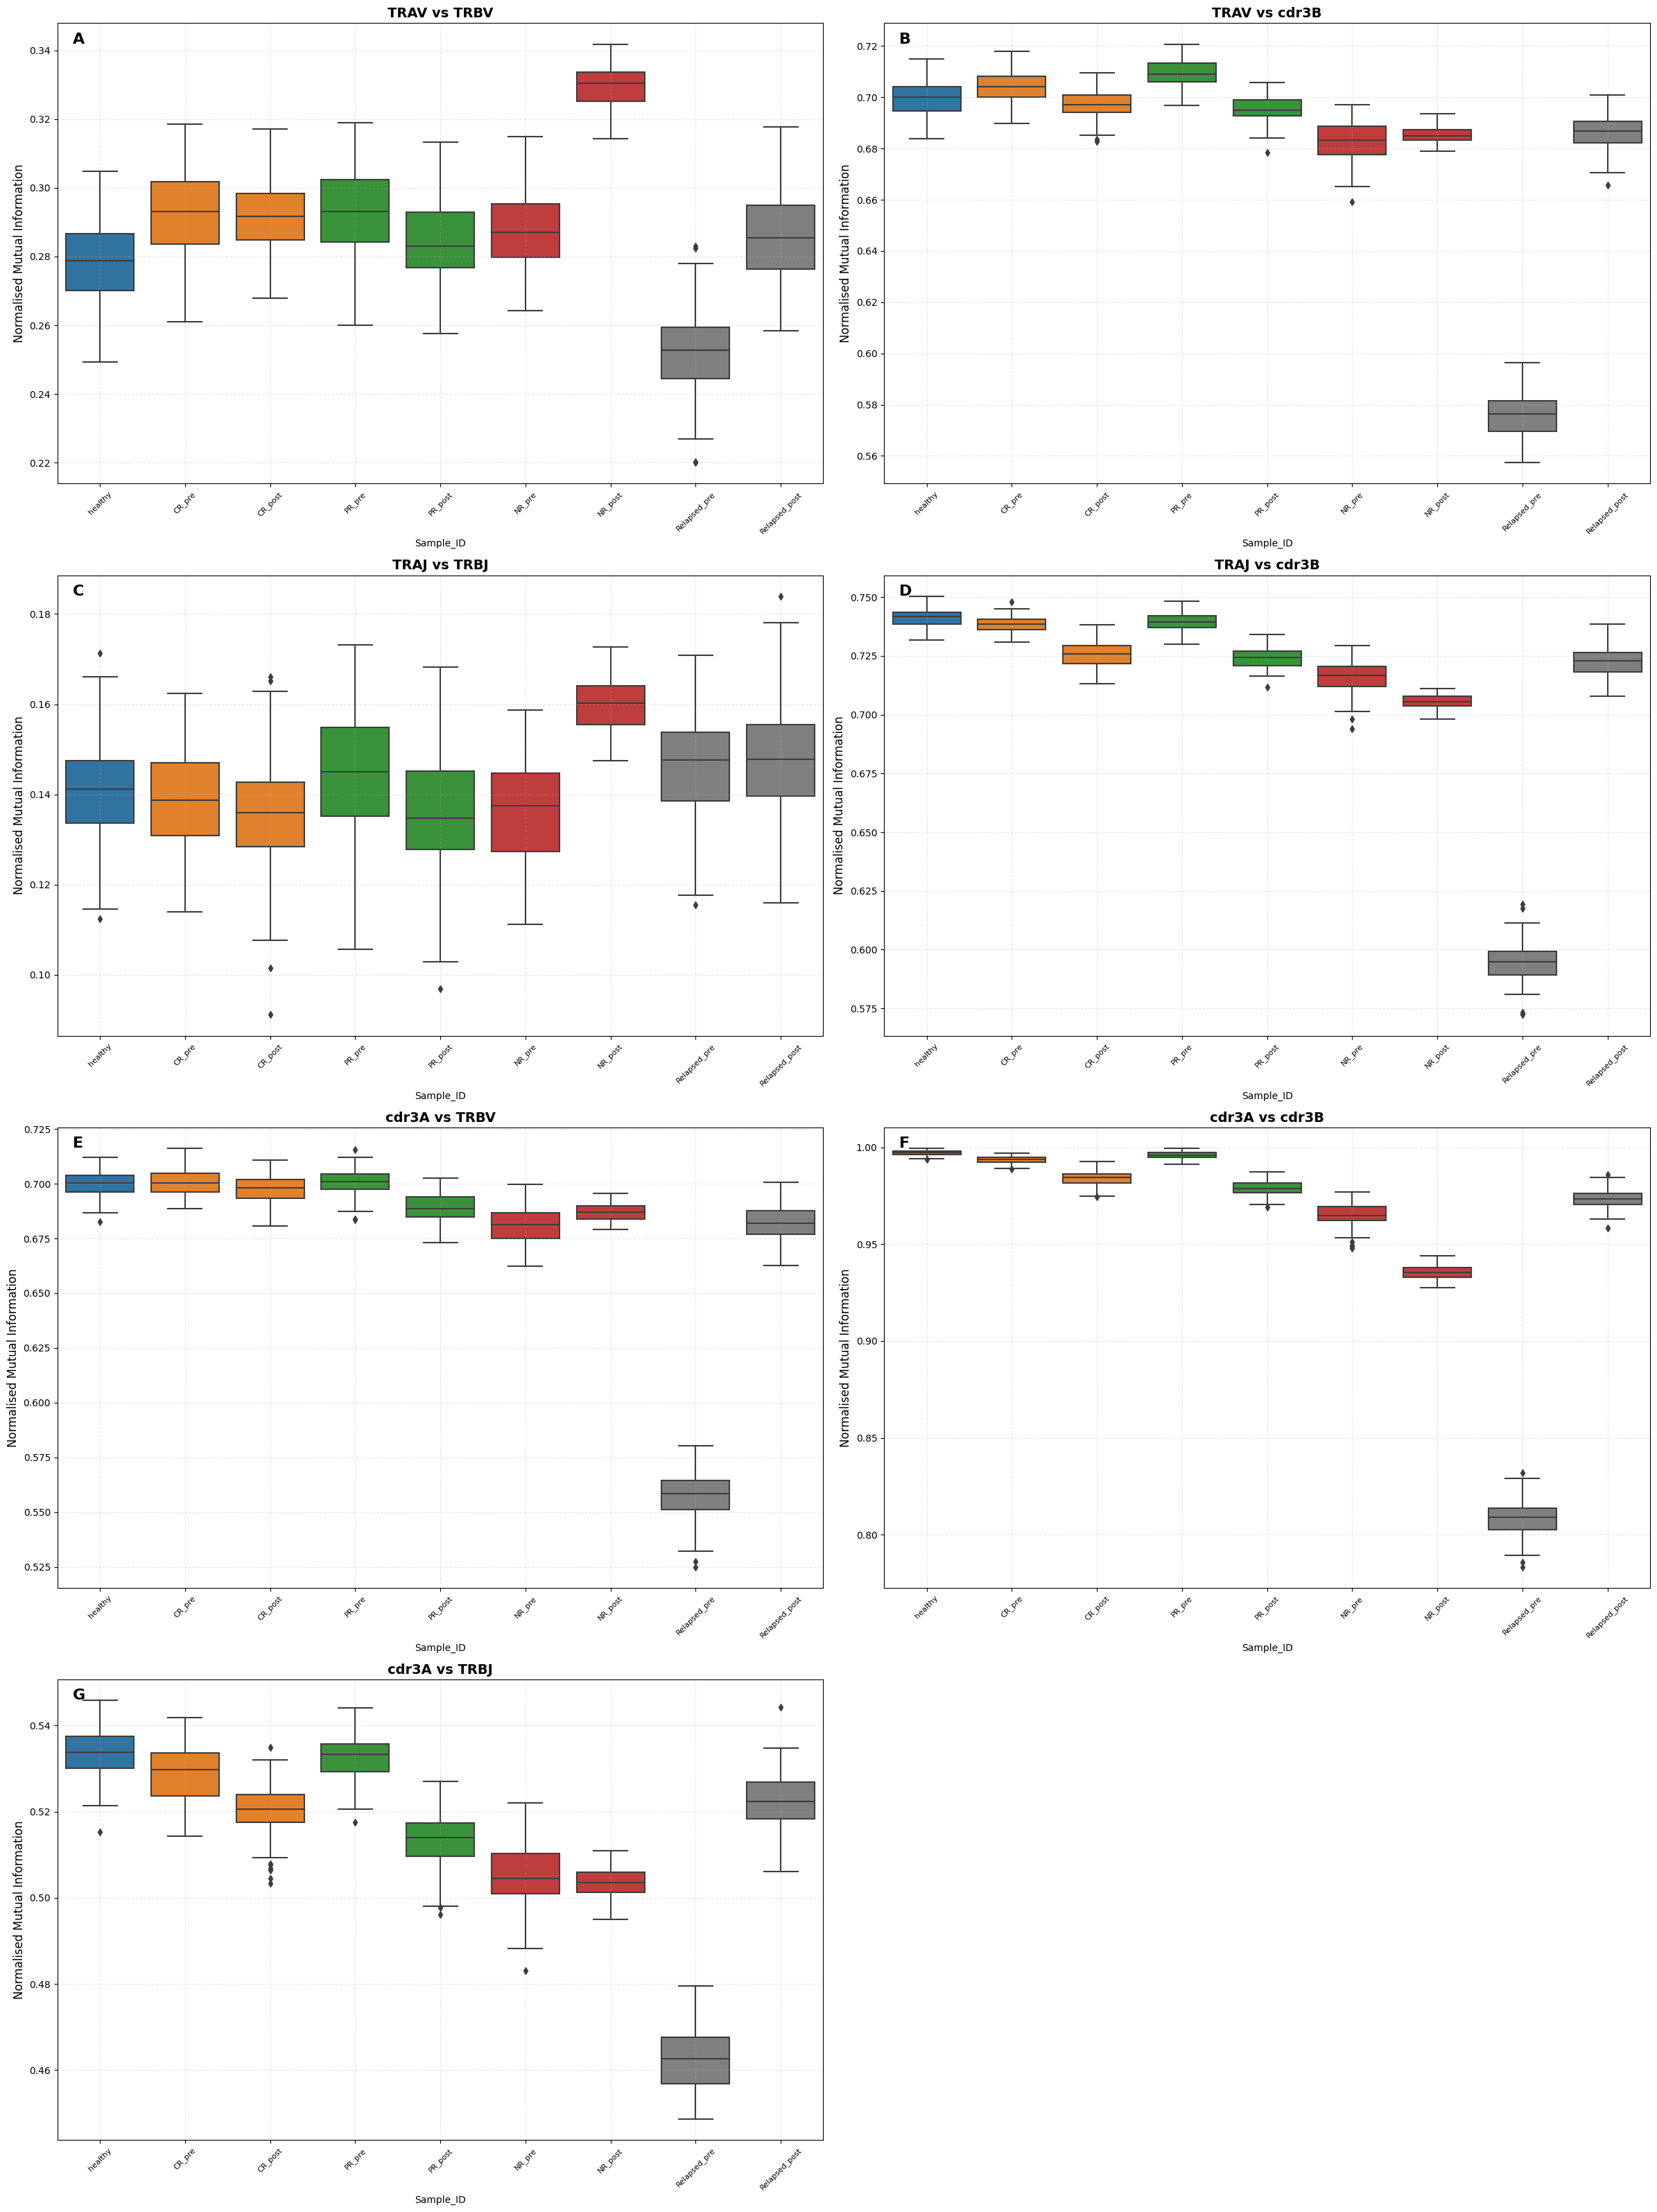

📊 Combined boxplot saved and displayed: combined_boxplots.pdf


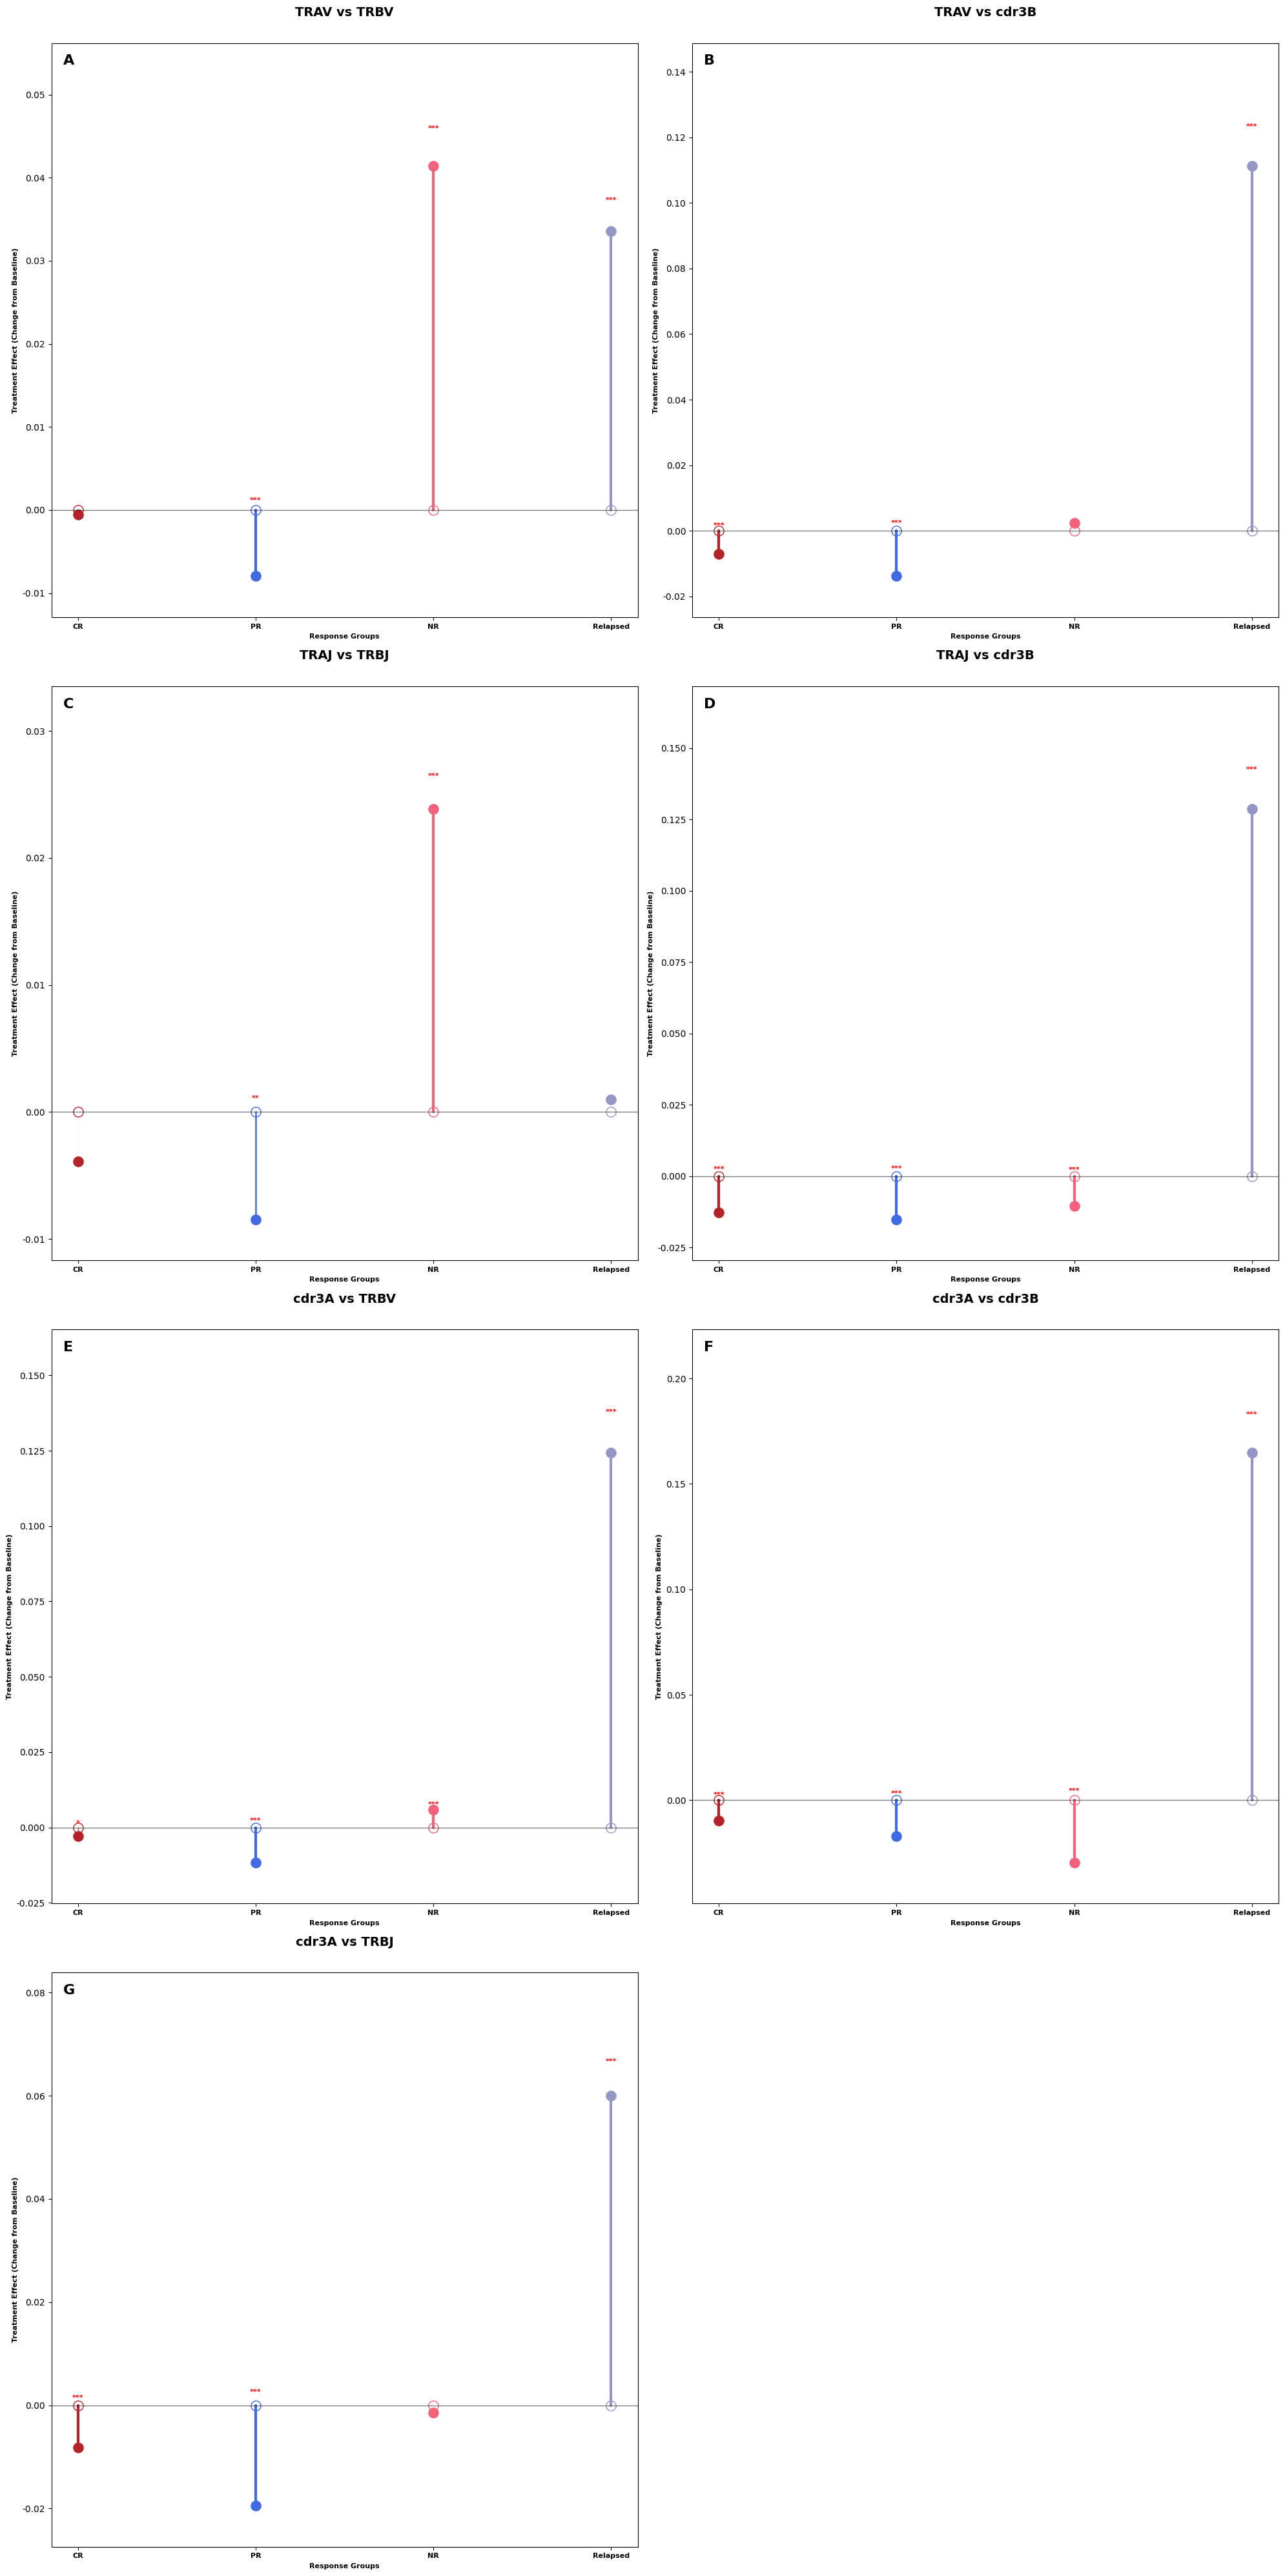

🔥 Combined heatmap saved and displayed: combined_heatmaps.pdf

✅ Processing completed. All figures saved to: figures/CTL/cohorts


In [9]:
create_mi_boxplot("/mnt/d/TCRMI/results/CTL/cohort/mi.pickle", 
                  "/mnt/d/TCRMI/results/CTL/cohort.pickle", 
                  analysis_type='cohort', save_dir="figures/CTL/cohorts",
                  selected_features=[('TRAV', 'TRBV'), ('cdr3A', 'cdr3B'),
                                    ('TRAV', 'cdr3B'), ('cdr3A', 'TRBV'),
                                    ('TRAJ', 'TRBJ'), ('cdr3A', 'TRBJ'),
                                    ('TRAJ', 'cdr3B'),])

# NPMI

In [13]:
F_TRBVs = tt.tr.query(contains_pattern="TRBV", functionality="F", precision="gene")
F_TRAVs = tt.tr.query(contains_pattern="TRAV", functionality="F", precision="gene")

F_TRBJs = tt.tr.query(contains_pattern="TRBJ", functionality="F", precision="gene")
F_TRAJs = tt.tr.query(contains_pattern="TRAJ", functionality="F", precision="gene")

In [14]:
def load_data(npmi_path, samples_path):
    """Load NPMI data and sample data"""
    npmi_data = pd.read_pickle(npmi_path)
    data_dict = pd.read_pickle(samples_path)
    return npmi_data, data_dict

def parse_sample_id(sample_id):
    """
    Parse sample ID to extract patient ID and timepoint
    Format: "UPN24 pretreatment", "UPN24 posttreatment", etc.
    """
    parts = sample_id.split(' ')
    if len(parts) >= 2:
        patient_id = parts[0]  # UPN24
        timepoint = parts[1]   # pretreatment/posttreatment
        return patient_id, timepoint
    else:
        return sample_id, 'unknown'

def get_patient_pairs(sample_ids):
    """
    Identify patients with both pre and post treatment samples
    
    Returns:
    --------
    dict: {patient_id: {'pretreatment': sample_id, 'posttreatment': sample_id}}
    """
    patient_timepoints = defaultdict(dict)
    
    for sample_id in sample_ids:
        patient_id, timepoint = parse_sample_id(sample_id)
        if timepoint in ['pretreatment', 'posttreatment']:
            patient_timepoints[patient_id][timepoint] = sample_id
    
    # Filter to only patients with both pre and post
    paired_patients = {}
    for patient_id, timepoints in patient_timepoints.items():
        if 'pretreatment' in timepoints and 'posttreatment' in timepoints:
            # Also check if patient has posttreatment data in sample_mapping
            if patient_id in sample_mapping and sample_mapping[patient_id]['posttreatment'] is not None:
                paired_patients[patient_id] = timepoints
    
    return paired_patients

In [16]:
def permutation_test_matrices(pre_matrices, post_matrices, n_permutations=10000, random_state=42):
    """
    Perform permutation test comparing pre vs post NPMI matrices
    
    Parameters:
    -----------
    pre_matrices: list of 2D numpy arrays (NPMI matrices from resamples)
    post_matrices: list of 2D numpy arrays (NPMI matrices from resamples)
    n_permutations: number of permutations for the test
    random_state: random seed
    
    Returns:
    --------
    tuple: (significant_positions, p_values, observed_differences)
    """
    if len(pre_matrices) == 0 or len(post_matrices) == 0:
        return None, None, None
    
    np.random.seed(random_state)
    
    # Stack matrices to get 3D arrays (n_resamples, n_genes1, n_genes2)
    pre_stack = np.stack(pre_matrices)
    post_stack = np.stack(post_matrices)
    
    # Get matrix dimensions
    n_genes1, n_genes2 = pre_stack.shape[1], pre_stack.shape[2]
    
    # Calculate observed differences (post - pre) for each gene pair
    pre_means = np.mean(pre_stack, axis=0)
    post_means = np.mean(post_stack, axis=0)
    observed_diff = post_means - pre_means
    
    # Initialize result arrays
    p_values = np.full((n_genes1, n_genes2), np.nan)
    significant_positions = np.zeros((n_genes1, n_genes2), dtype=bool)
    
    # Combine all values for permutation
    all_matrices = np.concatenate([pre_stack, post_stack], axis=0)
    n_pre = len(pre_matrices)
    n_post = len(post_matrices)
    n_total = n_pre + n_post
    
    # Test each gene pair position
    for i in range(n_genes1):
        for j in range(n_genes2):
            # Get values for this gene pair across all resamples
            pre_values = pre_stack[:, i, j]
            post_values = post_stack[:, i, j]
            all_values = all_matrices[:, i, j]
            
            # Only test if both pre and post have non-zero values
            #if np.any(pre_values != 0) and np.any(post_values != 0):
            # Calculate observed test statistic (difference in means)
            obs_stat = np.mean(post_values) - np.mean(pre_values)
            
            # Permutation test
            perm_stats = []
            for _ in range(n_permutations):
                # Randomly shuffle the combined data
                shuffled_indices = np.random.permutation(n_total)
                shuffled_values = all_values[shuffled_indices]
                
                # Split into "pseudo-pre" and "pseudo-post" groups
                pseudo_pre = shuffled_values[:n_pre]
                pseudo_post = shuffled_values[n_pre:]
                
                # Calculate permuted test statistic
                perm_stat = np.mean(pseudo_post) - np.mean(pseudo_pre)
                perm_stats.append(perm_stat)
            
            # Calculate p-value (two-tailed test)
            perm_stats = np.array(perm_stats)
            p_val = np.mean(np.abs(perm_stats) >= np.abs(obs_stat))
            p_values[i, j] = p_val
            
            # Check significance (you can adjust alpha as needed)
            if p_val < 0.05:
                significant_positions[i, j] = True
    
    return significant_positions, p_values, observed_diff

def analyze_patient_npmi_changes(npmi_data, data_dict, n_permutations=10000, alpha=0.05):
    """
    Analyze NPMI changes for each patient across all gene pairs using permutation tests
    
    Returns:
    --------
    dict: {patient_id: {feature_pair: {'significant_count': int, 'total_tested': int, 
                                      'significant_positions': array, 'p_values': array, 
                                      'observed_differences': array}}}
    """
    results = defaultdict(lambda: defaultdict(dict))
    
    # Get sample IDs from data_dict
    sample_ids = list(data_dict.keys())
    print(f"Total samples available: {len(sample_ids)}")
    
    # Get patients with both pre and post samples
    paired_patients = get_patient_pairs(sample_ids)
    print(f"Patients with both pre and post samples: {list(paired_patients.keys())}")
    
    # Process each feature pair
    for feature_pair in npmi_data.keys():
        feature1, feature2 = feature_pair
        print(f"\n{'='*60}")
        print(f"Analyzing feature pair: {feature1} vs {feature2}")
        
        # Get sample data for this feature pair
        sample_data = npmi_data[feature_pair]
        n_resamples = len(sample_data)
        print(f"Number of resamples: {n_resamples}")
        
        for patient_id, timepoints in paired_patients.items():
            print(f"\n  Processing patient: {patient_id}")
            
            pre_sample_id = timepoints['pretreatment']
            post_sample_id = timepoints['posttreatment']
            
            # Find indices of pre and post samples
            try:
                pre_idx = sample_ids.index(pre_sample_id)
                post_idx = sample_ids.index(post_sample_id)
                print(f"    Pre sample: {pre_sample_id} (index {pre_idx})")
                print(f"    Post sample: {post_sample_id} (index {post_idx})")
            except ValueError as e:
                print(f"    Error: Could not find sample indices for patient {patient_id}: {e}")
                continue
            
            # Collect NPMI matrices for all resamples
            pre_matrices = []
            post_matrices = []
            
            for resample_idx in range(n_resamples):
                if resample_idx in sample_data:
                    matrices = sample_data[resample_idx]
                    if pre_idx < len(matrices) and post_idx < len(matrices):
                        pre_matrices.append(matrices[pre_idx])
                        post_matrices.append(matrices[post_idx])
            
            if len(pre_matrices) == 0 or len(post_matrices) == 0:
                print(f"    Warning: No matrices found for patient {patient_id}")
                continue
            
            print(f"    Collected {len(pre_matrices)} pre matrices and {len(post_matrices)} post matrices")
            
            # Perform permutation test
            significant_positions, p_values, observed_diff = permutation_test_matrices(
                pre_matrices, post_matrices, n_permutations, random_state=42
            )
            
            if significant_positions is not None:
                # Count significant changes
                significant_count = np.sum(significant_positions)
                total_tested = np.sum(~np.isnan(p_values))
                
                results[patient_id][feature_pair] = {
                    'significant_count': significant_count,
                    'total_tested': total_tested,
                    'significant_positions': significant_positions,
                    'p_values': p_values,
                    'observed_differences': observed_diff,
                    'pre_sample_id': pre_sample_id,
                    'post_sample_id': post_sample_id,
                    'response_info': sample_mapping.get(patient_id, {})
                }
                
            else:
                print(f"    Warning: Could not perform test for patient {patient_id}")
    
    return results


In [17]:
def process_single_patient_feature_pair(patient_id, feature_pair, timepoints, sample_ids, 
                                       sample_data, n_resamples, n_permutations, sample_mapping):
    """
    Process a single patient-feature pair combination
    """
    pre_sample_id = timepoints['pretreatment']
    post_sample_id = timepoints['posttreatment']
    
    # Find indices of pre and post samples
    try:
        pre_idx = sample_ids.index(pre_sample_id)
        post_idx = sample_ids.index(post_sample_id)
    except ValueError as e:
        return patient_id, feature_pair, None, f"Could not find sample indices: {e}"
    
    # Collect NPMI matrices for all resamples
    pre_matrices = []
    post_matrices = []
    
    for resample_idx in range(n_resamples):
        if resample_idx in sample_data:
            matrices = sample_data[resample_idx]
            if pre_idx < len(matrices) and post_idx < len(matrices):
                pre_matrices.append(matrices[pre_idx])
                post_matrices.append(matrices[post_idx])
    
    if len(pre_matrices) == 0 or len(post_matrices) == 0:
        return patient_id, feature_pair, None, "No matrices found"
    
    # Perform permutation test
    significant_positions, p_values, observed_diff = permutation_test_matrices(
        pre_matrices, post_matrices, n_permutations, random_state=42
    )
    
    if significant_positions is not None:
        # Count significant changes
        significant_count = np.sum(significant_positions)
        total_tested = np.sum(~np.isnan(p_values))
        
        result = {
            'significant_count': significant_count,
            'total_tested': total_tested,
            'significant_positions': significant_positions,
            'p_values': p_values,
            'observed_differences': observed_diff,
            'pre_sample_id': pre_sample_id,
            'post_sample_id': post_sample_id,
            'response_info': sample_mapping.get(patient_id, {})
        }
        return patient_id, feature_pair, result, None
    else:
        return patient_id, feature_pair, None, "Could not perform test"

def analyze_patient_npmi_changes(npmi_data, data_dict, n_permutations=10000, alpha=0.05, n_jobs=-1):
    """
    Analyze NPMI changes for each patient across all gene pairs using permutation tests
    Accelerated with joblib parallel processing
    
    Parameters:
    -----------
    n_jobs : int, default=-1
        Number of parallel jobs. -1 means use all available cores
    
    Returns:
    --------
    dict: {patient_id: {feature_pair: {'significant_count': int, 'total_tested': int, 
                                      'significant_positions': array, 'p_values': array, 
                                      'observed_differences': array}}}
    """
    # Get sample IDs from data_dict
    sample_ids = list(data_dict.keys())
    print(f"Total samples available: {len(sample_ids)}")
    
    # Get patients with both pre and post samples
    paired_patients = get_patient_pairs(sample_ids)
    print(f"Patients with both pre and post samples: {list(paired_patients.keys())}")
    
    # Prepare all tasks for parallel processing
    tasks = []
    
    for feature_pair in npmi_data.keys():
        feature1, feature2 = feature_pair
        print(f"Preparing tasks for feature pair: {feature1} vs {feature2}")
        
        # Get sample data for this feature pair
        sample_data = npmi_data[feature_pair]
        n_resamples = len(sample_data)
        
        for patient_id, timepoints in paired_patients.items():
            tasks.append((
                patient_id, feature_pair, timepoints, sample_ids, 
                sample_data, n_resamples, n_permutations, sample_mapping
            ))
    
    print(f"Total tasks to process: {len(tasks)}")
    print(f"Running with {n_jobs} parallel jobs...")
    
    # Execute tasks in parallel
    parallel_results = Parallel(n_jobs=n_jobs, verbose=1)(
        delayed(process_single_patient_feature_pair)(
            patient_id, feature_pair, timepoints, sample_ids,
            sample_data, n_resamples, n_permutations, sample_mapping
        ) for patient_id, feature_pair, timepoints, sample_ids, 
             sample_data, n_resamples, n_permutations, sample_mapping in tasks
    )
    
    # Organize results
    results = defaultdict(lambda: defaultdict(dict))
    
    for patient_id, feature_pair, result, error in parallel_results:
        if result is not None:
            results[patient_id][feature_pair] = result
        else:
            print(f"Warning: Failed to process {patient_id} - {feature_pair}: {error}")
    
    print(f"\nCompleted processing for {len(results)} patients")
    
    return results

In [18]:
def summarize_patient_changes(analysis_results):
    """
    Summarize significant changes across all feature pairs for each patient
    
    Returns:
    --------
    pandas.DataFrame: Summary of changes per patient
    """
    summary_data = []
    
    for patient_id, feature_results in analysis_results.items():
        total_significant = 0
        total_tested = 0
        feature_counts = {}
        
        # Get patient info from sample_mapping
        patient_info = sample_mapping.get(patient_id, {})
        
        for feature_pair, results in feature_results.items():
            feature_name = f"{feature_pair[0]}_{feature_pair[1]}"
            significant_count = results['significant_count']
            tested_count = results['total_tested']
            
            total_significant += significant_count
            total_tested += tested_count
            feature_counts[f"{feature_name}_significant"] = significant_count
            feature_counts[f"{feature_name}_tested"] = tested_count
            feature_counts[f"{feature_name}_percentage"] = (significant_count / tested_count * 100) if tested_count > 0 else 0
        
        summary_row = {
            'Patient_ID': patient_id,
            'Total_Significant_Changes': total_significant,
            'Total_Gene_Pairs_Tested': total_tested,
            'Overall_Percentage_Changed': (total_significant / total_tested * 100) if total_tested > 0 else 0,
            'CMV_Status': patient_info.get('cmv_status', 'Unknown'),
            '3M_Response': patient_info.get('3M_response', 'Unknown'),
            '6M_Response': patient_info.get('6M_response', 'Unknown'),
            **feature_counts
        }
        
        summary_data.append(summary_row)
    
    return pd.DataFrame(summary_data)

def save_results(analysis_results, summary_df, output_dir):
    """Save analysis results"""
    os.makedirs(output_dir, exist_ok=True)
    
    # Convert defaultdict to regular dict for pickling
    regular_dict_results = {}
    for patient_id, feature_results in analysis_results.items():
        regular_dict_results[patient_id] = dict(feature_results)
    
    # Save detailed results
    with open(os.path.join(output_dir, 'patient_npmi_changes_detailed.pickle'), 'wb') as f:
        pickle.dump(regular_dict_results, f)
    
    # Save summary
    summary_df.to_csv(os.path.join(output_dir, 'patient_npmi_changes_summary.csv'), index=False)

In [19]:
npmi_data = pd.read_pickle("/mnt/d/TCRMI/results/CTL/samples/npmi.pickle")
metadata = pd.read_pickle("/mnt/d/TCRMI/results/CTL/samples.pickle")

In [20]:
analysis_results = analyze_patient_npmi_changes(npmi_data, metadata)

Total samples available: 31
Patients with both pre and post samples: ['UPN24', 'UPN10', 'UPN19', 'UPN18', 'UPN4', 'UPN17', 'UPN1', 'UPN12', 'UPN8', 'UPN13', 'UPN14', 'UPN15']
Preparing tasks for feature pair: TRAV vs TRBV
Preparing tasks for feature pair: TRAJ vs TRBJ
Total tasks to process: 24
Running with -1 parallel jobs...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.



Completed processing for 12 patients


[Parallel(n_jobs=-1)]: Done  24 out of  24 | elapsed: 21.4min finished


In [21]:
summary_df = summarize_patient_changes(analysis_results)

In [22]:
summary_df

,Patient_ID,Total_Significant_Changes,Total_Gene_Pairs_Tested,Overall_Percentage_Changed,CMV_Status,3M_Response,6M_Response,TRAV_TRBV_significant,TRAV_TRBV_tested,TRAV_TRBV_percentage,TRAJ_TRBJ_significant,TRAJ_TRBJ_tested,TRAJ_TRBJ_percentage
0,UPN24,384,2823,13.602550,Positive,CR,CR,278,2160,12.870370,106,663,15.987934
1,UPN10,382,2823,13.531704,Positive,CR,CR,286,2160,13.240741,96,663,14.479638
2,UPN19,443,2823,15.692526,Negative,PR,PR,329,2160,15.231481,114,663,17.194570
3,UPN18,237,2823,8.395324,Negative,PR,Relapsed,170,2160,7.870370,67,663,10.105581
4,UPN4,687,2823,24.335813,Positive,PR,Relapsed,479,2160,22.175926,208,663,31.372549
5,UPN17,1366,2823,48.388239,Positive,NR,"NR, off",1035,2160,47.916667,331,663,49.924585
6,UPN1,405,2823,14.346440,Positive,CR,CR,317,2160,14.675926,88,663,13.273002
7,UPN12,357,2823,12.646121,Negative,CR,CR,263,2160,12.175926,94,663,14.177979
8,UPN8,726,2823,25.717322,Positive,CR,CR,554,2160,25.648148,172,663,25.942685
9,UPN13,595,2823,21.076869,Negative,PR,PR,438,2160,20.277778,157,663,23.680241


In [23]:
save_results(analysis_results, summary_df, "/mnt/d/TCRMI/results/CTL/samples")

In [24]:
analysis_results = pd.read_pickle("results/CTL/samples/patient_npmi_changes_detailed.pickle")
summary_df = pd.read_csv("results/CTL/samples/patient_npmi_changes_summary.csv")

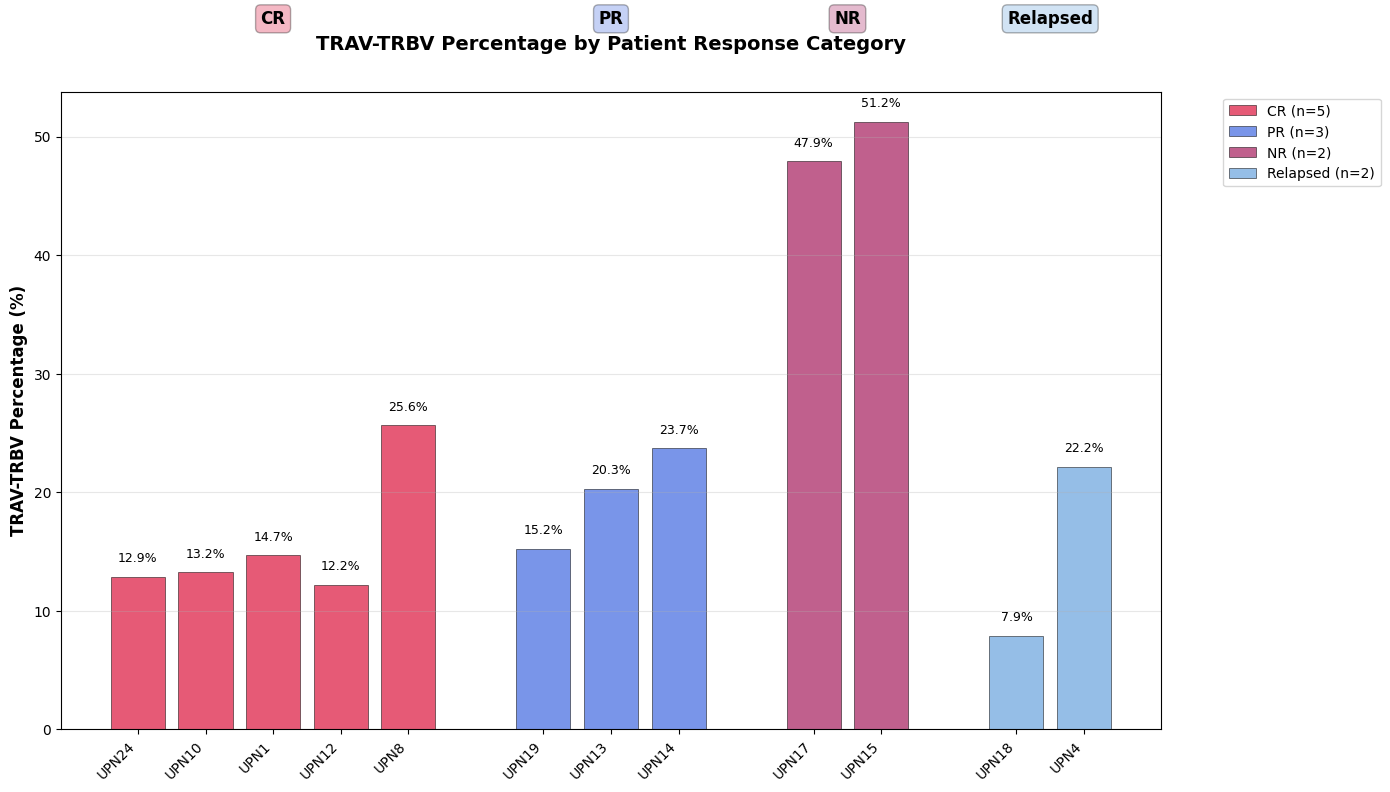

In [26]:
def plot_grouped_barplot(summary_df, figsize=(14, 8), type='TRAV_TRBV_percentage'):
    """
    Grouped bar plot with clear separation between response categories
    """
    # Define colors and order
    response_colors = {
        'CR': '#DC143C', 'PR': '#4169E1',
        'NR': '#A61C5D', 'Relapsed': '#69A3DD'
    }
    response_order = ['CR', 'PR', 'NR', 'Relapsed']
    
    # Prepare data
    summary_df['Response'] = summary_df['Patient_ID'].map(get_response_category).values
    summary_df['Response_order'] = summary_df['Response'].map({resp: i for i, resp in enumerate(response_order)})
    df_sorted = summary_df.sort_values('Response_order')
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create bars with spacing between groups
    x_pos = 0
    group_positions = []
    
    for response in response_order:
        if response in df_sorted['Response'].values:
            subset = df_sorted[df_sorted['Response'] == response]
            n_samples = len(subset)
            
            # Create bars for this group
            x_positions = np.arange(x_pos, x_pos + n_samples)
            bars = ax.bar(x_positions, subset[type], 
                         color=response_colors[response], alpha=0.7, 
                         edgecolor='black', linewidth=0.5,
                         label=f'{response} (n={n_samples})')
            
            # Add value labels on bars
            for i, (pos, val) in enumerate(zip(x_positions, subset[type])):
                ax.text(pos, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
            
            # Store group info
            group_positions.append((x_pos + n_samples/2 - 0.5, response))
            x_pos += n_samples + 1  # Add spacing
    
    # Set x-axis labels
    all_labels = []
    all_positions = []
    pos = 0
    
    for response in response_order:
        if response in df_sorted['Response'].values:
            subset = df_sorted[df_sorted['Response'] == response]
            for sample in subset['Patient_ID']:
                all_labels.append(sample)
                all_positions.append(pos)
                pos += 1
            pos += 1  # spacing_add_category_separators_and_labels
    
    ax.set_xticks(all_positions)
    ax.set_xticklabels(all_labels, rotation=45, ha='right')
    
    # Add group labels
    for pos, label in group_positions:
        ax.text(pos, ax.get_ylim()[1] * 1.1, label, ha='center', va='bottom', 
               fontweight='bold', fontsize=12,
               bbox=dict(boxstyle='round,pad=0.3', facecolor=response_colors[label], alpha=0.3))
    
    ax.set_ylabel('TRAV-TRBV Percentage (%)', fontsize=12, fontweight='bold')
    ax.set_title('TRAV-TRBV Percentage by Patient Response Category', 
                fontsize=14, fontweight='bold', pad=30)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()

plot_grouped_barplot(summary_df)
plt.savefig("/mnt/d/TCRMI/figures/CTL/cohorts/TRAV_TRBV_change.pdf", transparent=True)